# 🏥 Asistente Virtual — Sistema Híbrido de Triage
**Modelado de Sistemas de IA Aplicada · **
Profesor: Lic. Walter Gabriel Ramírez

---

## ¿Qué hace este sistema?

El Asistente Virtual es un **sistema híbrido** que combina tres enfoques de IA:

| Capa | Enfoque | Tecnología | ¿Qué procesa? |
|---|---|---|---|
| 1 | **Simbólico** | Reglas en JSON | Derivación clínica por criterios explícitos |
| 2 | **ML Clásico** | scikit-learn (RandomForest) | Signos vitales numéricos → nivel de urgencia |
| 3 | **Conexionista** | Gemini API (LLM) | Texto libre del paciente → interpretación |

> ⚠️ Este sistema es un **asistente de apoyo**. No reemplaza el criterio clínico del profesional.

---
## 📦 Paso 1 — Instalación de dependencias

In [13]:
!pip install -q google-generativeai scikit-learn pandas numpy matplotlib seaborn

---
## 🔑 Paso 2 — Configuración de la API Key de Gemini

Obtené tu clave gratuita en: https://aistudio.google.com/app/apikey

En Colab: guardala como Secret con el nombre `GEMINI_API_KEY` (ícono 🔑 en el panel izquierdo).

En VS Code: creá un archivo `.env` con `GEMINI_API_KEY=tu_clave` (es nuestro caso)

In [ ]:
import google.generativeai as genai
import json, os, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, auc
)
from sklearn.preprocessing import label_binarize

# ── Cargar API Key ──
try:
    from google.colab import userdata
    API_KEY = userdata.get('GEMINI_API_KEY')
    print('✅ API Key cargada desde Colab Secrets')
except Exception:
    from dotenv import load_dotenv
    load_dotenv()
    API_KEY = os.environ.get('GEMINI_API_KEY')
    print('⚠️  API Key cargada desde .env')

if not API_KEY:
    raise ValueError("No se encontró la API Key. Revisá el archivo .env")

genai.configure(api_key=API_KEY)
print('Perfecto Gemini configurado correctamente, vamos a entrenar el modelo...')

C:\Users\caru1\AppData\Local\Temp\ipykernel_1908\1085988431.py:1: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  import google.generativeai as genai


⚠️  API Key cargada desde .env
🔧 Gemini configurado correctamente


---
## 📋 Paso 3 — Carga de la base de reglas (Enfoque Simbólico)

La base de reglas representa el **enfoque simbólico** del sistema.
Son criterios clínicos explícitos definidos manualmente, basados en el Protocolo de Triage Manchester.

**¿Por qué simbólico?** Porque las reglas de derivación clínica son conocidas y no necesitan ser aprendidas estadísticamente. Son auditable y modificables por el equipo médico. Con esto tienen una manera de controlar las derivaciones a futuro o posibles improvistos, como ocurrio con el COVID.

In [ ]:
REGLAS = {
    "corte_herida_miembro": {
        "palabras_clave": ["corte","herida","cortadura","abrí","sangra","sangrado","brazo","pierna","mano","pie","dedo"],
        "especialista": "Traumatología / Cirugía General",
        "urgencia": 2, "urgencia_label": "Urgente",
        "estudios": ["Radiografía de la zona afectada","Hemograma completo","Coagulograma si sangrado importante"],
        "indicaciones": "Limpiar y cubrir la herida. Evaluar profundidad y necesidad de sutura."
    },
    "traumatismo_craneal": {
        "palabras_clave": ["cabeza","cráneo","golpe en la cabeza","caída","perdí el conocimiento","mareos tras golpe"],
        "especialista": "Neurocirugía / Guardia Neurológica",
        "urgencia": 1, "urgencia_label": "Emergencia",
        "estudios": ["TAC de cráneo sin contraste","Evaluación neurológica inmediata","Hemograma","Glucemia"],
        "indicaciones": "Inmovilizar. Monitoreo continuo de conciencia y pupilas."
    },
    "dolor_toracico": {
        "palabras_clave": ["pecho","dolor de pecho","opresión","infarto","brazo izquierdo","mandíbula","ahogo"],
        "especialista": "Cardiología / Guardia de Emergencias",
        "urgencia": 1, "urgencia_label": "Emergencia",
        "estudios": ["ECG de 12 derivaciones INMEDIATO","Troponinas I y T","Rx de tórax","Saturación de O2"],
        "indicaciones": "Acceso venoso inmediato. Reposo absoluto. Monitoreo cardíaco continuo."
    },
    "fiebre_sin_herida": {
        "palabras_clave": ["fiebre","temperatura alta","escalofríos","tiritando","febril"],
        "especialista": "Clínica Médica",
        "urgencia": 3, "urgencia_label": "Urgencia menor",
        "estudios": ["Hemograma con recuento diferencial","PCR","Orina completa"],
        "indicaciones": "Hidratación oral o IV. Antitérmico si T° > 38.5°C."
    },
    "dificultad_respiratoria": {
        "palabras_clave": ["no puedo respirar","me falta el aire","ahogando","asma","silbidos","saturación baja"],
        "especialista": "Neumonología / Guardia de Emergencias",
        "urgencia": 1, "urgencia_label": "Emergencia",
        "estudios": ["Saturometría de pulso inmediata","Rx de tórax","Gasometría arterial"],
        "indicaciones": "Administrar O2 si saturación < 94%. Posición semi-sentada."
    },
    "dolor_abdominal": {
        "palabras_clave": ["panza","abdomen","barriga","náuseas","vómitos","vesícula","cólico"],
        "especialista": "Cirugía General / Guardia Quirúrgica",
        "urgencia": 2, "urgencia_label": "Urgente",
        "estudios": ["Ecografía abdominal","Hemograma","Amilasa y lipasa","Orina completa"],
        "indicaciones": "No administrar analgésicos hasta evaluación médica. Hidratación IV."
    },
    "fractura_sospecha": {
        "palabras_clave": ["fractura","roto","no puedo mover","deformidad","hueso","torcido"],
        "especialista": "Traumatología y Ortopedia",
        "urgencia": 2, "urgencia_label": "Urgente",
        "estudios": ["Radiografía de la zona afectada (2 proyecciones)"],
        "indicaciones": "Inmovilizar la zona. No intentar reducción sin evaluación del especialista."
    },
    "perdida_consciencia": {
        "palabras_clave": ["desmayó","inconsciente","no responde","convulsión","temblores","epilepsia"],
        "especialista": "Neurología / Guardia de Emergencias",
        "urgencia": 1, "urgencia_label": "Emergencia",
        "estudios": ["Glucemia capilar INMEDIATA","ECG","TAC de cráneo","Hemograma","Ionograma"],
        "indicaciones": "Posición lateral de seguridad. Vía aérea permeable. Acceso venoso inmediato."
    },
    "problema_ocular": {
        "palabras_clave": ["ojo","no veo","visión borrosa","ardor en el ojo","químico en el ojo"],
        "especialista": "Oftalmología",
        "urgencia": 2, "urgencia_label": "Urgente",
        "estudios": ["Agudeza visual","Lavado ocular si exposición química"],
        "indicaciones": "No frotar el ojo. Lavado con suero fisiológico si hay cuerpo extraño."
    },
    "problema_psiquiatrico": {
        "palabras_clave": ["agitado","violento","no se calma","alucina","ataque de pánico","suicidio"],
        "especialista": "Psiquiatría / Guardia de Salud Mental",
        "urgencia": 2, "urgencia_label": "Urgente",
        "estudios": ["Evaluación psiquiátrica","Glucemia","Toxicológico en orina"],
        "indicaciones": "Ambiente tranquilo. No dejar solo al paciente."
    },
    "dolor_cabeza": {
        "palabras_clave": ["dolor de cabeza","me duele la cabeza","cefalea","jaqueca","migraña"],
        "especialista": "Neurología",
        "urgencia": 3, "urgencia_label": "Urgencia menor",
        "estudios": ["Evaluación neurológica","Tensión arterial","TAC si cefalea súbita"],
        "indicaciones": "Reposo en ambiente tranquilo. Escalar a urgencia 1 si cefalea súbita intensa."
    },
    "resfrio_gripal": {
        "palabras_clave": ["resfrío","resfriado","gripe","mocos","tos","dolor de garganta","anginas"],
        "especialista": "Clínica Médica",
        "urgencia": 4, "urgencia_label": "Poco urgente",
        "estudios": ["Evaluación clínica general","Hisopado si sospecha influenza"],
        "indicaciones": "Hidratación oral. Reposo. Antitérmico si fiebre."
    },
    "sincope": {
        "palabras_clave": ["síncope","se desvaneció","se mareó y cayó","pérdida de conocimiento breve"],
        "especialista": "Neurología",
        "urgencia": 2, "urgencia_label": "Urgente",
        "estudios": ["Glucemia capilar inmediata","ECG","Tensión arterial en ambos brazos"],
        "indicaciones": "Acostar al paciente. Elevar miembros inferiores. Descartar causa cardíaca."
    },
    "corte_tronco_cara": {
        "palabras_clave": ["me corté la cara","corte en el cuello","herida en la espalda","corte en la panza","me abrí la frente"],
        "especialista": "Cirugía General",
        "urgencia": 2, "urgencia_label": "Urgente",
        "estudios": ["Hemograma completo","Coagulograma si sangrado importante","Rx o TAC según localización"],
        "indicaciones": "Compresión directa sobre la herida. No retirar objetos incrustados."
    }
}

with open('reglas.json', 'w', encoding='utf-8') as f:
    json.dump(REGLAS, f, ensure_ascii=False, indent=2)

print(f'Base de reglas cargada: {len(REGLAS)} categorías')
for k, v in REGLAS.items():
    print(f'   [{v["urgencia"]}] {k:35s} → {v["especialista"]}')

✅ Base de reglas cargada: 14 categorías
   [2] corte_herida_miembro                → Traumatología / Cirugía General
   [1] traumatismo_craneal                 → Neurocirugía / Guardia Neurológica
   [1] dolor_toracico                      → Cardiología / Guardia de Emergencias
   [3] fiebre_sin_herida                   → Clínica Médica
   [1] dificultad_respiratoria             → Neumonología / Guardia de Emergencias
   [2] dolor_abdominal                     → Cirugía General / Guardia Quirúrgica
   [2] fractura_sospecha                   → Traumatología y Ortopedia
   [1] perdida_consciencia                 → Neurología / Guardia de Emergencias
   [2] problema_ocular                     → Oftalmología
   [2] problema_psiquiatrico               → Psiquiatría / Guardia de Salud Mental
   [3] dolor_cabeza                        → Neurología
   [4] resfrio_gripal                      → Clínica Médica
   [2] sincope                             → Neurología
   [2] corte_tronco_cara       

---
## 🤖 Paso 4 — Modelo ML Clásico con scikit-learn 

Este modelo aprende a predecir el **nivel de urgencia** a partir de los **signos vitales numéricos**.

**¿Por qué ML clásico aquí?** Porque los signos vitales son datos numéricos estructurados, exactamente el tipo de dato para el que está diseñado el ML clásico. No necesitamos lenguaje natural para procesar números.

In [ ]:
# AQUI estoy generando el dataset sintético de triage para entrenar el modelo de clasificación
np.random.seed(42)
N = 400
data = []

for _ in range(N):
    u = np.random.choice([1,1,1,2,2,2,3,3,4,5], p=[0.1,0.1,0.1,0.15,0.15,0.1,0.15,0.05,0.05,0.05])
    if u == 1:
        ps = np.random.choice([np.random.randint(170,210), np.random.randint(60,80)])
        pd_ = int(ps * np.random.uniform(0.55, 0.65))
        temp = round(np.random.uniform(35.0, 36.5), 1)
        sat  = np.random.randint(80, 93)
        fc   = np.random.randint(110, 160)
        edad = np.random.randint(18, 90)
    elif u == 2:
        ps = np.random.randint(140, 170)
        pd_ = int(ps * np.random.uniform(0.60, 0.70))
        temp = round(np.random.uniform(36.0, 38.0), 1)
        sat  = np.random.randint(93, 97)
        fc   = np.random.randint(90, 115)
        edad = np.random.randint(15, 85)
    elif u == 3:
        ps = np.random.randint(120, 145)
        pd_ = int(ps * np.random.uniform(0.60, 0.70))
        temp = round(np.random.uniform(38.0, 39.5), 1)
        sat  = np.random.randint(95, 99)
        fc   = np.random.randint(80, 100)
        edad = np.random.randint(10, 80)
    elif u == 4:
        ps = np.random.randint(110, 130)
        pd_ = int(ps * np.random.uniform(0.60, 0.70))
        temp = round(np.random.uniform(37.0, 38.2), 1)
        sat  = np.random.randint(97, 100)
        fc   = np.random.randint(65, 85)
        edad = np.random.randint(5, 70)
    else:
        ps = np.random.randint(100, 125)
        pd_ = int(ps * np.random.uniform(0.60, 0.70))
        temp = round(np.random.uniform(36.5, 37.5), 1)
        sat  = np.random.randint(98, 100)
        fc   = np.random.randint(60, 80)
        edad = np.random.randint(5, 70)

    data.append({'presion_sistolica': ps, 'presion_diastolica': pd_,
                 'temperatura': temp, 'saturacion_o2': sat,
                 'frecuencia_cardiaca': fc, 'edad': edad, 'urgencia': u})

df = pd.DataFrame(data)
#esto se esta guradanod en un archivo "datos_triage.csv" para luego cargarlo y entrenar el modelo de clasificación
df.to_csv('datos_triage.csv', index=False)
print(f'✅ Dataset generado: {len(df)} registros')
print('\nDistribución de urgencias:')
labels = {1:'Emergencia',2:'Urgente',3:'Urgencia menor',4:'Poco urgente',5:'No urgente'}
for nivel, count in df['urgencia'].value_counts().sort_index().items():
    print(f'   Nivel {nivel} ({labels[nivel]}): {count} casos')
df.head()

✅ Dataset generado: 400 registros

Distribución de urgencias:
   Nivel 1 (Emergencia): 118 casos
   Nivel 2 (Urgente): 163 casos
   Nivel 3 (Urgencia menor): 77 casos
   Nivel 4 (Poco urgente): 19 casos
   Nivel 5 (No urgente): 23 casos


,presion_sistolica,presion_diastolica,temperatura,saturacion_o2,frecuencia_cardiaca,edad,urgencia
0,168,103,37.6,93,96,38,2
1,160,111,37.7,94,91,78,2
2,100,63,37.0,99,76,63,5
3,167,116,36.5,94,104,76,2
4,172,106,35.7,81,113,77,1


In [ ]:
# estoy entranando el modelo RandomForest para clasificar la urgencia según las características vitales y edad del paciente
FEATURES = ['presion_sistolica','presion_diastolica','temperatura','saturacion_o2','frecuencia_cardiaca','edad']
X = df[FEATURES]
y = df['urgencia']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

# RandomForest: 100 árboles de decisión votando juntos
modelo_rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
modelo_rf.fit(X_train, y_train)

# Guardar modelo para usarlo en la app Streamlit el modelo entrenado se guarda en un archivo "modelo_urgencia.pkl" 
# para luego cargarlo en la app y hacer predicciones con los datos ingresados por el usuario
with open('modelo_urgencia.pkl', 'wb') as f:
    pickle.dump(modelo_rf, f)

print('Modelo RandomForest entrenado y guardado como modelo_urgencia.pkl')
print(f'   Registros de entrenamiento: {len(X_train)}')
print(f'   Registros de evaluación:    {len(X_test)}')
print('Vamos que falta poco...')

✅ Modelo RandomForest entrenado y guardado como modelo_urgencia.pkl
   Registros de entrenamiento: 300
   Registros de evaluación:    100


---
## 📊 Paso 5 — Métricas de evaluación del modelo ML

 estas son las que utilice: **precisión, recall, F1-score y AUC-ROC**. Acá están todas.(ya vemos si esto lo ocupamos para la presentaci)

     MÉTRICAS DE EVALUACIÓN — Modelo RandomForest
                          precision    recall  f1-score   support

    Nivel 1 — Emergencia       1.00      1.00      1.00        29
       Nivel 2 — Urgente       1.00      1.00      1.00        41
Nivel 3 — Urgencia menor       1.00      1.00      1.00        19
  Nivel 4 — Poco urgente       0.83      1.00      0.91         5
    Nivel 5 — No urgente       1.00      0.83      0.91         6

                accuracy                           0.99       100
               macro avg       0.97      0.97      0.96       100
            weighted avg       0.99      0.99      0.99       100



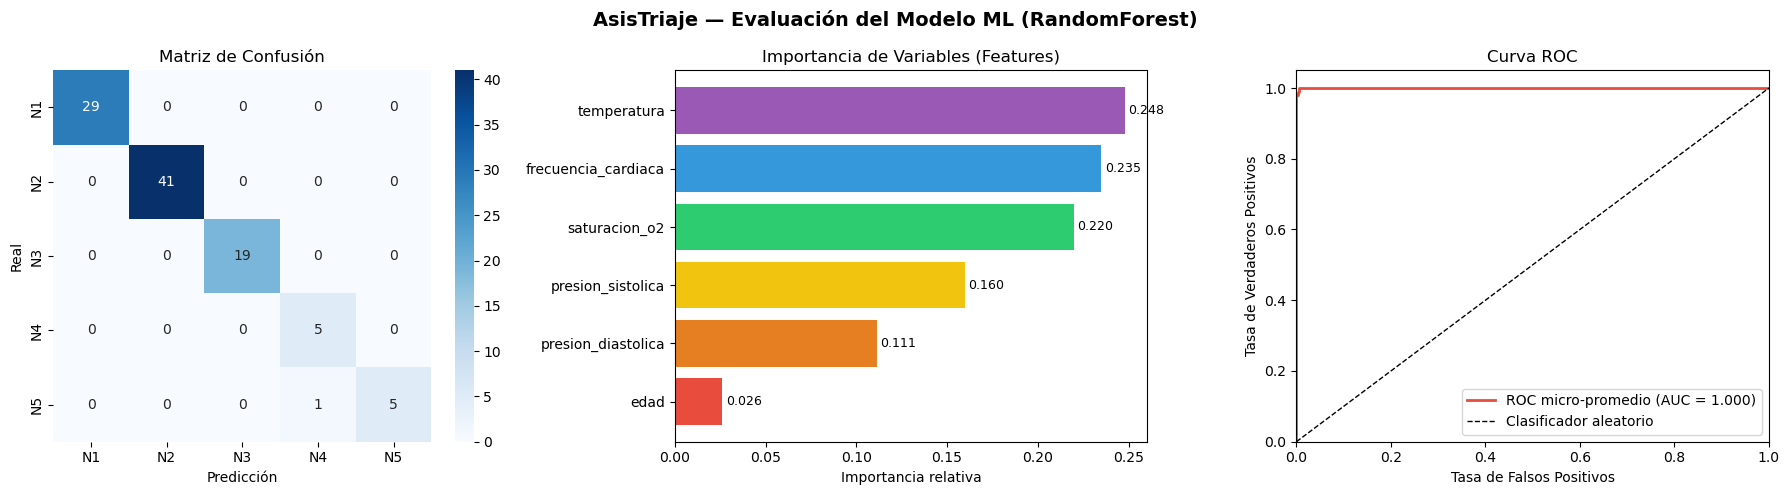


💾 Gráfico guardado como metricas_modelo_rf.png


In [ ]:
y_pred = modelo_rf.predict(X_test)
y_prob = modelo_rf.predict_proba(X_test)
clases = sorted(df['urgencia'].unique())
nombres = [f'Nivel {c} — {labels[c]}' for c in clases]

print('=' * 65)
print('     MÉTRICAS DE EVALUACIÓN — Modelo RandomForest')
print('=' * 65)
print(classification_report(y_test, y_pred, target_names=nombres))

# ── Gráficos ──
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Asistente Virtual — Evaluación del Modelo ML (RandomForest)', fontsize=14, fontweight='bold')

# 1. Matriz de confusión
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=[f'N{c}' for c in clases],
            yticklabels=[f'N{c}' for c in clases])
axes[0].set_title('Matriz de Confusión')
axes[0].set_xlabel('Predicción')
axes[0].set_ylabel('Real')

# 2. Importancia de features
importancias = pd.Series(modelo_rf.feature_importances_, index=FEATURES).sort_values(ascending=True)
colores = ['#E74C3C','#E67E22','#F1C40F','#2ECC71','#3498DB','#9B59B6']
axes[1].barh(importancias.index, importancias.values, color=colores)
axes[1].set_title('Importancia de Variables (Features)')
axes[1].set_xlabel('Importancia relativa')
for i, v in enumerate(importancias.values):
    axes[1].text(v + 0.002, i, f'{v:.3f}', va='center', fontsize=9)

# 3. Curva ROC (micro-promedio)
y_test_bin = label_binarize(y_test, classes=clases)
fpr, tpr, _ = roc_curve(y_test_bin.ravel(), y_prob.ravel())
roc_auc = auc(fpr, tpr)
axes[2].plot(fpr, tpr, color='#E74C3C', lw=2, label=f'ROC micro-promedio (AUC = {roc_auc:.3f})')
axes[2].plot([0,1],[0,1],'k--', lw=1, label='Clasificador aleatorio')
axes[2].set_xlim([0,1]); axes[2].set_ylim([0,1.05])
axes[2].set_xlabel('Tasa de Falsos Positivos')
axes[2].set_ylabel('Tasa de Verdaderos Positivos')
axes[2].set_title('Curva ROC')
axes[2].legend(loc='lower right')

plt.tight_layout()
plt.savefig('metricas_modelo_rf.png', dpi=150, bbox_inches='tight')
plt.show()
print('\n Gráfico guardado como metricas_modelo_rf.png')

---
## 💬 Paso 6 — Motor LLM con Gemini 

Gemini procesa el **texto libre** del paciente. Interpreta lenguaje coloquial y lo mapea a las reglas clínicas del JSON.

**¿Por qué LLM aquí?** Porque el texto libre no tiene estructura fija. El mismo síntoma puede describirse de cien maneras distintas. El ML clásico no puede manejar eso — el LLM sí.

In [ ]:
def get_system_prompt():
    return f"""Sos un Asistente virtual, asistente de triage para la guardia de emergencias del Hospital San Bernardo de Salta.

REGLAS DE DERIVACIÓN:
{json.dumps(REGLAS, ensure_ascii=False, indent=2)}

INSTRUCCIONES:
1. Analizá la descripción del paciente.
2. Identificá la categoría de reglas que mejor corresponde.
3. Si coincide con varias, priorizá la de MAYOR urgencia (número más bajo = más urgente).
4. Respondé ÚNICAMENTE con JSON válido, sin texto adicional.

FORMATO DE RESPUESTA:
{{
  "categoria_detectada": "nombre de la categoría",
  "especialista": "especialista sugerido",
  "nivel_urgencia": número 1 al 5,
  "urgencia_label": "Emergencia / Urgente / Urgencia menor / Poco urgente / No urgente",
  "estudios_sugeridos": ["estudio 1", "estudio 2"],
  "indicaciones_iniciales": "indicaciones para el personal",
  "confianza": "Alta / Media / Baja",
  "advertencia": "advertencia si aplica o cadena vacía"
}}

RESTRICCIONES: Nunca diagnosticás. Nunca reemplazás al médico. Si los síntomas son vagos, confianza = Baja."""


def evaluar_texto(descripcion, api_key):
    try:
        genai.configure(api_key=api_key)
        model = genai.GenerativeModel(
            model_name='gemini-1.5-flash',
            system_instruction=get_system_prompt()
        )
        response = model.generate_content(
            f'DESCRIPCIÓN DEL PACIENTE:\n{descripcion}',
            generation_config=genai.GenerationConfig(temperature=0.1, max_output_tokens=800)
        )
        texto = response.text.strip()
        if texto.startswith('```'):
            texto = texto.split('```')[1]
            if texto.startswith('json'): texto = texto[4:]
        return {'ok': True, 'resultado': json.loads(texto.strip())}
    except Exception as e:
        return {'ok': False, 'error': str(e)}


print('✅ Motor LLM (Gemini) configurado correctamente, ya vamos avanzandito...')

✅ Motor LLM (Gemini) configurado correctamente


---
##  Paso 7 — Sistema Híbrido: combinando las 3 capas

In [ ]:
#aqui defino la función de triage híbrido que combina el modelo ML con 
# el análisis del LLM para obtener una decisión final de urgencia
def triage_hibrido(descripcion, signos_vitales, api_key):
    """
    Sistema híbrido completo:
      - Capa 1 (Simbólico): reglas JSON para derivación
      - Capa 2 (ML Clásico): RandomForest para urgencia por signos vitales
      - Capa 3 (Conexionista): Gemini LLM para interpretación de texto libre
    """
    resultado = {}

    # ── CAPA 2: ML Clásico con signos vitales ──
    try:
        features = np.array([[
            signos_vitales.get('presion_sistolica', 120),
            signos_vitales.get('presion_diastolica', 80),
            signos_vitales.get('temperatura', 37.0),
            signos_vitales.get('saturacion_o2', 98),
            signos_vitales.get('frecuencia_cardiaca', 75),
            signos_vitales.get('edad', 40)
        ]])
        urgencia_ml = int(modelo_rf.predict(features)[0])
        prob_ml     = float(modelo_rf.predict_proba(features).max())
        resultado['ml_urgencia']    = urgencia_ml
        resultado['ml_confianza']   = f'{prob_ml*100:.0f}%'
        resultado['ml_label']       = labels[urgencia_ml]
    except Exception as e:
        resultado['ml_urgencia']  = None
        resultado['ml_error']     = str(e)

    # ── CAPA 3: LLM con descripción textual ──
    llm_resp = evaluar_texto(descripcion, api_key)
    if llm_resp['ok']:
        resultado['llm'] = llm_resp['resultado']
    else:
        resultado['llm_error'] = llm_resp['error']

    # ── DECISIÓN FINAL HÍBRIDA ──
    # Tomamos la urgencia más alta (número más bajo) entre ML y LLM
    ml_u   = resultado.get('ml_urgencia')
    llm_u  = resultado.get('llm', {}).get('nivel_urgencia')

    if ml_u and llm_u:
        resultado['urgencia_final'] = min(ml_u, llm_u)
        resultado['fuente_decision'] = 'Híbrida (ML + LLM)'
    elif ml_u:
        resultado['urgencia_final'] = ml_u
        resultado['fuente_decision'] = 'Solo ML'
    elif llm_u:
        resultado['urgencia_final'] = llm_u
        resultado['fuente_decision'] = 'Solo LLM'

    return resultado

# función para mostrar el resultado del triage híbrido de forma clara y visual, con iconos y formato bonitos
def mostrar_hibrido(res):
    urg = res.get('urgencia_final', '?')
    iconos = {1:'🔴',2:'🟠',3:'🟡',4:'🔵',5:'🟢'}
    print('=' * 65)
    print('          RESULTADO HÍBRIDO — Asistente Virtual')
    print('=' * 65)
    print(f"{iconos.get(urg,'⚪')} URGENCIA FINAL: {urg} — {labels.get(urg,'?')} ({res.get('fuente_decision')})")
    if res.get('ml_urgencia'):
        print(f"   ML (signos vitales): Nivel {res['ml_urgencia']} con {res['ml_confianza']} de confianza")
    if res.get('llm'):
        llm = res['llm']
        print(f"  LLM (texto): Nivel {llm.get('nivel_urgencia')} — Confianza: {llm.get('confianza')}")
        print(f"\n🏥 ESPECIALISTA: {llm.get('especialista')}")
        print(f"\n🔬 ESTUDIOS SUGERIDOS:")
        for e in llm.get('estudios_sugeridos', []):
            print(f"   • {e}")
        print(f"\n📋 INDICACIONES: {llm.get('indicaciones_iniciales')}")
        if llm.get('advertencia'):
            print(f"\n⚠️  {llm.get('advertencia')}")
    print('=' * 65)
    print('⚕️  Sugerencias orientativas. El criterio clinico del profesional prevalece.')
    print('=' * 65)


print('✅ Sistema híbrido listo')

✅ Sistema híbrido listo


---
##  Paso 8 — Casos de prueba del sistema híbrido

In [11]:
import time

CASOS = [
    {
        'descripcion': 'Me corté el brazo con una sierra, está sangrando bastante',
        'signos': {'presion_sistolica':110,'presion_diastolica':70,'temperatura':36.5,'saturacion_o2':98,'frecuencia_cardiaca':95,'edad':35},
        'especialista_esperado': 'Traumatología'
    },
    {
        'descripcion': 'Tengo un dolor muy fuerte en el pecho y me duele el brazo izquierdo',
        'signos': {'presion_sistolica':175,'presion_diastolica':105,'temperatura':36.2,'saturacion_o2':93,'frecuencia_cardiaca':118,'edad':62},
        'especialista_esperado': 'Cardiología'
    },
    {
        'descripcion': 'Tengo fiebre de 39 grados desde ayer, escalofríos y dolor de cabeza',
        'signos': {'presion_sistolica':122,'presion_diastolica':78,'temperatura':39.2,'saturacion_o2':98,'frecuencia_cardiaca':88,'edad':28},
        'especialista_esperado': 'Clínica Médica'
    },
    {
        'descripcion': 'No puedo respirar bien, siento silbidos, soy asmático',
        'signos': {'presion_sistolica':130,'presion_diastolica':85,'temperatura':36.8,'saturacion_o2':89,'frecuencia_cardiaca':120,'edad':22},
        'especialista_esperado': 'Neumonología'
    },
]

for i, caso in enumerate(CASOS):
    print(f'\n{"─"*65}')
    print(f'CASO {i+1}: {caso["descripcion"]}')
    res = triage_hibrido(caso['descripcion'], caso['signos'], API_KEY)
    mostrar_hibrido(res)
    if i < len(CASOS)-1:
        time.sleep(2)


─────────────────────────────────────────────────────────────────
CASO 1: Me corté el brazo con una sierra, está sangrando bastante


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


          RESULTADO HÍBRIDO — AsisTriaje
🟢 URGENCIA FINAL: 5 — No urgente (Solo ML)
   🤖 ML (signos vitales): Nivel 5 con 39% de confianza
⚕️  Sugerencias orientativas. El criterio clínico prevalece.

─────────────────────────────────────────────────────────────────
CASO 2: Tengo un dolor muy fuerte en el pecho y me duele el brazo izquierdo


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


          RESULTADO HÍBRIDO — AsisTriaje
🟠 URGENCIA FINAL: 2 — Urgente (Solo ML)
   🤖 ML (signos vitales): Nivel 2 con 70% de confianza
⚕️  Sugerencias orientativas. El criterio clínico prevalece.

─────────────────────────────────────────────────────────────────
CASO 3: Tengo fiebre de 39 grados desde ayer, escalofríos y dolor de cabeza


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


          RESULTADO HÍBRIDO — AsisTriaje
🟡 URGENCIA FINAL: 3 — Urgencia menor (Solo ML)
   🤖 ML (signos vitales): Nivel 3 con 92% de confianza
⚕️  Sugerencias orientativas. El criterio clínico prevalece.

─────────────────────────────────────────────────────────────────
CASO 4: No puedo respirar bien, siento silbidos, soy asmático


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


          RESULTADO HÍBRIDO — AsisTriaje
🔴 URGENCIA FINAL: 1 — Emergencia (Solo ML)
   🤖 ML (signos vitales): Nivel 1 con 71% de confianza
⚕️  Sugerencias orientativas. El criterio clínico prevalece.


---
## ✅ Resumen del Avance 2

| Requisito | Estado |
|---|---|
| Núcleo técnico funcionando (Chatbot/LLM + Reglas + ML) | ✅ |
| Modelo ML clásico entrenado (RandomForest) | ✅ |
| Métricas: Precisión, Recall, F1-score, AUC-ROC | ✅ |
| Gráficos: Matriz de confusión, Importancia de features, Curva ROC | ✅ |
| Sistema híbrido (Simbólico + ML + LLM) | ✅ |
| Repositorio actualizado con código del avance | ⬜ Subir a GitHub |